# Phase 1 — GENIE v19.0 Preprocessing & Alteration Matrix Construction

**Purpose**: this notebook does three things, not just one:
1. **Organize** the raw AACR GENIE public release into a single panel-aware
   alteration table (`data/processed/alterations_long.parquet`) that Phase 2+
   notebooks will use instead of the raw 1 GB MAF / 421 MB CNA files.
2. **Filter** the raw mutation calls down to the ones likely to actually
   matter for cancer: somatic only (not inherited), protein-changing only
   (not silent), uncommon in the healthy population (not a common germline
   polymorphism), and -- for missense calls -- backed by AlphaMissense
   and/or Polyphen+SIFT agreement, or a cancerhotspots.org recurrent-site
   match (Section 3c, the rule Jason approved) -- so what remains is
   likely-pathogenic mutations, not every raw variant call.
3. **Track testing coverage** by building `panel_gene_coverage.parquet` --
   recording exactly which gene was tested on which panel. Without this, a
   gene absent from a sample's results is ambiguous (never tested, or
   tested and clean?). Example: if gene X is only on a small panel used
   for 800 of 5,000 Lung Cancer samples, and 40 of those 800 show it
   altered, the true rate is 40/800 = 5% -- but treating all 5,000 as
   tested would wrongly give 40/5,000 = 0.8%, a number that just reflects
   which panel was used, not real biology. `panel_gene_coverage.parquet`
   is what lets Phase 2 always divide by the correct denominator (only
   samples actually tested for the gene(s) in question).

**Inputs**: `data/data_mutations_extended.txt`, `data/data_CNA.txt`,
`data/data_clinical_sample.txt`, `data/data_clinical_patient.txt`,
`data/genomic_information.txt`

**Outputs** (written to `data/processed/`):
- `clinical_tidy.parquet`
- `panel_gene_coverage.parquet`
- `alterations_long.parquet`
- `alphamissense_filtered.parquet` (cached AlphaMissense scores for our gene set)
- `putative_biallelic_tsg_events.parquet` (shallow-del + damaging-mutation two-hit TSG feature, external to `alterations_long`)
- `consensus_genes_global.parquet` (pooled-cohort gene list, for cross-cancer-type comparisons only)
- `consensus_genes_per_cancer_type.parquet` (per-cancer-type gene list, the one actually used for within-cancer-type work)
- `qc_summary.json`

This notebook is self-contained -- all loading/filtering logic is defined
in the cell below rather than imported from a separate script. See `PLAN.md`
for the full multi-phase project plan and the rationale for each filtering choice. Filter thresholds are provisional — flagged
for confirmation with the supervisor before Phase 2.

## Phase 1 data flow, at a glance

```text
data_clinical_sample.txt (271,837 rows)   data_clinical_patient.txt (227,696 rows)
   [1 row per SAMPLE]                            [1 row per PATIENT]
              \                                         /
               \----------  merge on PATIENT_ID  ------/
                                    |
                                    v
                  clinical_tidy.parquet (271,837 rows)
     Purpose: attach cancer type + panel ID + survival info to every sample


genomic_information.txt (867,541 exon-level rows, 167 panels)
              |
              |  keep includeInPanel == True,
              |  collapse exon rows -> 1 row per (panel, gene)
              v
     panel_gene_coverage.parquet (53,291 rows -- gene level, not exon
     level: 1 row per unique (panel, gene) pair, exon coordinates dropped)
     Purpose: answer "was gene X tested on panel Y?" so a gene missing
     from a sample's results can be told apart as "not mutated" vs.
     "never tested" in the first place


data_mutations_extended.txt (3,458,550 rows)
              |
              |  1. col Mutation_Status: keep "Somatic"/"SOMATIC" only
              |     ................................ 3,434,978 left
              |  2. col Variant_Classification: keep protein-changing
              |     types only (Missense, Nonsense, Frame_Shift_*,
              |     In_Frame_*, Splice_Site, ...), drop Silent/Intron/UTR
              |     ................................ 2,590,981 left
              |  3. cols gnomAD_AF + 8 subpopulation AF cols: drop row
              |     if the max of these is > 1e-4 -- common in a
              |     healthy population means likely inherited
              |     (germline), not a tumor-specific mutation
              |     ................................ 2,486,986 left
              |  4. non-missense rows (nonsense, frameshift, ...) are
              |     untouched from here on and always kept. Missense
              |     rows go through the pathogenicity-evidence step below.
              v
     [somatic, protein-altering, non-germline mutations -- missense
      rows still need one more decision]


              missense rows only, from the block above
                            |
              (Sections 3a/3b: build the evidence, compare candidate
              rules against the OLD rule below before choosing)
                            |
                            v
     OLD rule (superseded): Polyphen "damaging" OR SIFT "deleterious"
              -> 1,832,135 total rows (all classes) if used
                            |
     FINAL rule (Section 3c, Jason-approved): AlphaMissense = "pathogenic"
              OR (Polyphen = "damaging" AND SIFT = "deleterious"),
              rescued by a cancerhotspots.org recurrent-residue match
              if the above still fails
                            v
     mutations  (1,597,106 rows, Alteration_Type = "MUT")
     Purpose: keep only mutations likely to be real and damaging --
     now backed by 3 independent predictors + real-world recurrence,
     not just 2 older, higher-false-positive tools


data_CNA.txt (~173,494,500 gene x sample cells)
              |
              |  col value at each (gene, sample) cell: keep only
              |  strong signals, -2 (deep deletion) or 2 (amplification);
              |  drop 0 / weak calls (-1, 1) / NA (gene not on panel).
              |  Settled (not pending): shallow calls (-1) don't need to
              |  be their own signal here -- used instead as supporting
              |  evidence in the two-hit feature just below.
              v
     cna_altered  (377,216 rows, Alteration_Type = "CNV")
     Purpose: keep only high-confidence copy-number changes


mutations (1,597,106 rows)  +  shallow deletions (-1 / -1.5) on the
   406 OncoKB-curated tumour-suppressor genes only
              |
              |  a TSG gene "hits" twice if the SAME sample has both a
              |  shallow deletion AND a damaging mutation on it -- one
              |  copy lost, the other disabled (Knudson two-hit model)
              v
     putative_biallelic_tsg_events.parquet (23,632 gene events --
     "putative" since bulk sequencing can't prove the two hits are on
     different copies; matches cBioPortal/TCGA's own caveat here)
     Purpose: a side confidence signal for TSG mutations, kept separate
     from alterations_long rather than double-counted into it


mutations (1,597,106 rows, from the block above)
  +  cna_altered (377,216 rows, from the block above)
              |
              |  stack the two tables together (pd.concat), then attach
              |  CANCER_TYPE + SEQ_ASSAY_ID by looking up each Sample_ID
              |  in clinical_tidy (the very first block of this diagram)
              v
     alterations_long.parquet (1,974,322 rows, 229,361 unique samples)
     Purpose: ONE clean table of "which gene was altered, HOW (mutation
     type + protein change, or CNV direction), in which sample, in
     which cancer type" -- everything Phase 2+ needs


panel_gene_coverage.parquet + clinical_tidy.parquet
              |
              |  for each gene, what fraction of samples' panels cover
              |  it -- checked TWO ways (Section 8): pooled across
              |  all cancer types (global), and separately within each
              |  cancer type (per-cancer-type). Global collapses to a
              |  small, cancer-type-blind list; per-cancer-type doesn't.
              v
     consensus_genes_global.parquet (190 genes, >=80% of ALL 271,837
     samples) -- kept only for whenever cancer types must be pooled
     consensus_genes_per_cancer_type.parquet (705 distinct genes total,
     >=80% coverage AND >=100 tested samples WITHIN each cancer type;
     median 241 genes/cancer type, range 30-531) -- the list Phase 2
     actually uses for within-cancer-type work


all the counts above
              |
              v
     qc_summary.json
     Purpose: record how many rows were dropped at each step, so every
     filtering choice is checkable instead of buried in code
```


In [1]:
import json
from pathlib import Path

import pandas as pd

pd.set_option("display.max_columns", 50)
qc_summary = {}

DATA_DIR = Path.cwd().parent / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

# Variant_Classification values kept as "protein-altering" (candidate pathogenic).
# Silent/Intron/UTR/Flank/RNA/IGR are dropped -- they don't change protein sequence.
PROTEIN_ALTERING_CLASSES = {
    "Missense_Mutation",
    "Nonsense_Mutation",
    "Frame_Shift_Del",
    "Frame_Shift_Ins",
    "In_Frame_Del",
    "In_Frame_Ins",
    "Splice_Site",
    "Translation_Start_Site",
    "Nonstop_Mutation",
}

GNOMAD_AF_COLS = [
    "gnomAD_AF", "gnomAD_AFR_AF", "gnomAD_AMR_AF", "gnomAD_ASJ_AF",
    "gnomAD_EAS_AF", "gnomAD_FIN_AF", "gnomAD_NFE_AF", "gnomAD_OTH_AF",
    "gnomAD_SAS_AF",
]

# Common germline polymorphism cutoff: exclude anything above this AF in any
# gnomAD subpopulation (rare somatic drivers are essentially absent from gnomAD).
GERMLINE_AF_CUTOFF = 1e-4

# t_ref_count/t_alt_count/t_depth: tumor read counts, kept for VAF (variant allele
# frequency = t_alt_count / t_depth) -- not used for filtering yet, but needed
# later to check whether a two-hit event's mutation VAF looks consistent with
# being the sole remaining copy (a real confidence check, not yet built).
MUTATION_USECOLS = [
    "Hugo_Symbol", "Variant_Classification", "Tumor_Sample_Barcode",
    "Mutation_Status", "HGVSp_Short", "Polyphen_Prediction", "SIFT_Prediction",
    "t_ref_count", "t_alt_count", "t_depth",
] + GNOMAD_AF_COLS


def load_clinical() -> pd.DataFrame:
    """Merge sample- and patient-level clinical tables into one tidy frame."""
    sample = pd.read_csv(RAW_DIR / "data_clinical_sample.txt", sep="\t", comment="#")
    patient = pd.read_csv(RAW_DIR / "data_clinical_patient.txt", sep="\t", comment="#")
    return sample.merge(patient, on="PATIENT_ID", how="left")


def load_panel_gene_coverage() -> pd.DataFrame:
    """
    Authoritative panel coverage from genomic_information.txt.
    Returns long frame (SEQ_ASSAY_ID, Hugo_Symbol) for genes actually assayed
    (includeInPanel == True), deduplicated. This is the denominator mask
    needed for any later frequency / co-occurrence calculation.

    Also attaches, from assay_information.txt (PANEL-level, not gene-level --
    every gene on a given panel shares the same capability), the raw
    `alteration_types` string and a derived `cna_capable` boolean. Only 48 of
    167 panels can call CNAs at all (checked directly); a gene "covered" by a
    mutation-only panel was sequenced, but that panel could never produce a
    CNV call for it regardless of true biology. Not yet used to change any
    coverage/denominator logic -- exposed here so that decision can be made
    deliberately downstream, not implied silently.
    """
    genomic = pd.read_csv(
        RAW_DIR / "genomic_information.txt", sep="\t",
        usecols=["Hugo_Symbol", "SEQ_ASSAY_ID", "includeInPanel"],
    )
    covered = genomic.loc[genomic["includeInPanel"] == True, ["SEQ_ASSAY_ID", "Hugo_Symbol"]]
    covered = covered.drop_duplicates().reset_index(drop=True)

    assay = pd.read_csv(RAW_DIR / "assay_information.txt", sep="\t", usecols=["SEQ_ASSAY_ID", "alteration_types"])
    assay["cna_capable"] = assay["alteration_types"].astype(str).str.contains("gene_level_cna", na=False)
    covered = covered.merge(assay, on="SEQ_ASSAY_ID", how="left")

    return covered


def load_mutations_pathogenic() -> pd.DataFrame:
    """
    Load data_mutations_extended.txt filtered down to likely-pathogenic somatic
    calls: protein-altering class, somatic status, not a common germline
    polymorphism, and (for missense only) Polyphen/SIFT deleterious support.
    Returns long frame tagged Alteration_Type == 'MUT'.
    """
    dtype = {
        "Hugo_Symbol": "category",
        "Variant_Classification": "category",
        "Mutation_Status": "category",
        "Polyphen_Prediction": "category",
        "SIFT_Prediction": "category",
    }
    muts = pd.read_csv(
        RAW_DIR / "data_mutations_extended.txt", sep="\t",
        usecols=MUTATION_USECOLS, dtype=dtype, low_memory=False,
    )
    n_raw = len(muts)

    muts = muts[muts["Mutation_Status"].isin(["Somatic", "SOMATIC"])]
    n_somatic = len(muts)

    muts = muts[muts["Variant_Classification"].isin(PROTEIN_ALTERING_CLASSES)]
    n_protein_altering = len(muts)

    max_af = muts[GNOMAD_AF_COLS].max(axis=1, skipna=True)
    muts = muts[(max_af.isna()) | (max_af <= GERMLINE_AF_CUTOFF)]
    n_not_germline = len(muts)

    is_missense = muts["Variant_Classification"] == "Missense_Mutation"
    damaging = muts["Polyphen_Prediction"].astype(str).str.contains("damaging", case=False, na=False)
    deleterious = muts["SIFT_Prediction"].astype(str).str.contains("deleterious", case=False, na=False)
    muts = muts[~is_missense | damaging | deleterious]
    n_final = len(muts)

    muts = muts.rename(columns={"Tumor_Sample_Barcode": "Sample_ID"})
    muts["Alteration_Type"] = "MUT"
    muts["VAF"] = muts["t_alt_count"] / muts["t_depth"]

    muts.attrs["qc_counts"] = {
        "raw_rows": n_raw,
        "after_somatic_filter": n_somatic,
        "after_protein_altering_filter": n_protein_altering,
        "after_germline_af_filter": n_not_germline,
        "after_missense_evidence_filter": n_final,
    }
    return muts[[
        "Sample_ID", "Hugo_Symbol", "Alteration_Type", "Variant_Classification",
        "HGVSp_Short", "t_ref_count", "t_alt_count", "t_depth", "VAF",
    ]]


def load_cna_altered(min_level: int = 2) -> pd.DataFrame:
    """
    Load data_CNA.txt (Hugo_Symbol x Sample wide matrix, values in
    {-2,-1,0,1,2,NA}; NA = gene not on that sample's panel) and return only
    the altered calls as a long frame, tagged Alteration_Type == 'CNV'.
    min_level=2 keeps only deep deletion (-2) / amplification (2); pass 1 to
    also include shallow gain/loss (-1/1).
    """
    cna = pd.read_csv(RAW_DIR / "data_CNA.txt", sep="\t", index_col="Hugo_Symbol")
    levels = [2, -2] if min_level >= 2 else [2, -2, 1, -1]
    mask = cna.isin(levels)
    # pandas >= 2.1's stack() no longer drops NaN by default (future_stack=True
    # is forced from pandas 3.0 on) -- dropna() explicitly to keep only altered calls.
    altered = cna.where(mask).stack().dropna()
    long = altered.rename("CNA_value").reset_index()
    long.columns = ["Hugo_Symbol", "Sample_ID", "CNA_value"]
    long["Alteration_Type"] = "CNV"
    cna_direction = {2: "Amplification", 1: "Gain", -1: "Loss", -2: "Deep_Deletion"}
    long["CNA_Direction"] = long["CNA_value"].map(cna_direction)
    return long

## 1. Clinical data (sample + patient merge)

In [2]:
clinical = load_clinical()
print(clinical.shape)
clinical.head(3)

(271837, 19)


,PATIENT_ID,SAMPLE_ID,AGE_AT_SEQ_REPORT,ONCOTREE_CODE,SAMPLE_TYPE,SEQ_ASSAY_ID,CANCER_TYPE,CANCER_TYPE_DETAILED,SAMPLE_TYPE_DETAILED,SAMPLE_CLASS,SEX,PRIMARY_RACE,ETHNICITY,CENTER,INT_CONTACT,INT_DOD,YEAR_CONTACT,DEAD,YEAR_DEATH
0,GENIE-CHOP-C1002819,GENIE-CHOP-C1002819-BS79B4V9EZ,11,UNKNOWN,Primary,CHOP-STNGS,UNKNOWN,UNKNOWN,Primary tumor,Tumor,Female,White,Non-Spanish/non-Hispanic,CHOP,5714,Not Applicable,2022,FALSE,Not Applicable
1,GENIE-CHOP-C1002942,GENIE-CHOP-C1002942-BS7MEH2Z48,6,AML,Not Applicable or Heme,CHOP-HEMEP,Leukemia,Acute Myeloid Leukemia,Not applicable or hematologic malignancy,Tumor,Female,White,Non-Spanish/non-Hispanic,CHOP,Unknown,2608,Unknown,TRUE,2018
2,GENIE-CHOP-C1002942,GENIE-CHOP-C1002942-BS3YSSSEPK,7,AML,Not Applicable or Heme,CHOP-HEMEP,Leukemia,Acute Myeloid Leukemia,Not applicable or hematologic malignancy,Tumor,Female,White,Non-Spanish/non-Hispanic,CHOP,Unknown,2608,Unknown,TRUE,2018


In [3]:
cancer_type_counts = clinical["CANCER_TYPE"].value_counts()
qc_summary["n_samples_total"] = int(len(clinical))
qc_summary["n_cancer_types"] = int(cancer_type_counts.shape[0])
cancer_type_counts.head(20)

CANCER_TYPE
Non-Small Cell Lung Cancer      39553
Colorectal Cancer               23312
Breast Cancer                   21929
Glioma                          16106
Mature B-Cell Neoplasms         12304
Pancreatic Cancer               11760
Leukemia                        10836
Melanoma                        10203
Ovarian Cancer                   9549
Prostate Cancer                  9251
Endometrial Cancer               8794
Cancer of Unknown Primary        8385
Soft Tissue Sarcoma              7662
Esophagogastric Cancer           7478
Bladder Cancer                   7142
UNKNOWN                          6197
Hepatobiliary Cancer             5405
Myeloproliferative Neoplasms     5068
Renal Cell Carcinoma             3891
Myelodysplastic Syndromes        3837
Name: count, dtype: int64

In [4]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
clinical.to_parquet(PROCESSED_DIR / "clinical_tidy.parquet", index=False)

## 2. Panel gene coverage

This is the denominator mask for everything downstream: a gene absent from a
sample's mutation/CNA record could mean "wild-type" or "never tested" —
`genomic_information.txt` (`includeInPanel`) disambiguates the two.

In [5]:
panel_coverage = load_panel_gene_coverage()
print(panel_coverage.shape)
genes_per_panel = panel_coverage.groupby("SEQ_ASSAY_ID")["Hugo_Symbol"].nunique().sort_values(ascending=False)
qc_summary["n_panels"] = int(genes_per_panel.shape[0])
qc_summary["genes_per_panel_median"] = float(genes_per_panel.median())
genes_per_panel.describe()

(53291, 4)


count      167.000000
mean       318.622754
std       1457.355294
min          1.000000
25%         48.500000
50%        105.000000
75%        335.000000
max      18849.000000
Name: Hugo_Symbol, dtype: float64

In [6]:
panel_coverage.to_parquet(PROCESSED_DIR / "panel_gene_coverage.parquet", index=False)

## 3. Pathogenic mutation filtering

Filter funnel (see the `load_mutations_pathogenic` function defined above):
1. Somatic status only
2. Protein-altering `Variant_Classification` only
3. Drop likely-germline variants (gnomAD AF > 1e-4 in any subpopulation)
4. For missense calls specifically, require Polyphen "damaging" or SIFT
   "deleterious" support (**superseded below in 3d** -- kept here only as
   the baseline Sections 3a/3b compare against)

In [7]:
mutations = load_mutations_pathogenic()
qc_summary["mutation_filter_funnel"] = mutations.attrs["qc_counts"]
mutations.attrs["qc_counts"]

{'raw_rows': 3458550,
 'after_somatic_filter': 3434978,
 'after_protein_altering_filter': 2590981,
 'after_germline_af_filter': 2486986,
 'after_missense_evidence_filter': 1832135}

In [8]:
print(mutations.shape)
mutations.head()

(1832135, 9)


,Sample_ID,Hugo_Symbol,Alteration_Type,Variant_Classification,HGVSp_Short,t_ref_count,t_alt_count,t_depth,VAF
0,GENIE-JHU-00006-00185,KRAS,MUT,Missense_Mutation,p.G12C,1247.0,376.0,1623.0,0.231670
1,GENIE-JHU-00006-00185,BRAF,MUT,Missense_Mutation,p.V600E,913.0,118.0,1031.0,0.114452
3,GENIE-JHU-00006-00185,TP53,MUT,Missense_Mutation,p.R273H,820.0,110.0,930.0,0.118280
6,GENIE-JHU-00006-00185,CTNNB1,MUT,Missense_Mutation,p.Q26R,748.0,67.0,815.0,0.082209
7,GENIE-JHU-00006-00185,CTNNB1,MUT,Missense_Mutation,p.S33F,721.0,98.0,819.0,0.119658


### 3a. AlphaMissense cross-check (led to the rule applied in 3c)

Jason asked for AlphaMissense to be added alongside Polyphen/SIFT, but didn't
specify AND vs. OR. Rather than guess, this section builds the join and reports
both, without changing the production filter above -- the winning rule from
this comparison is applied for real in Section 3c.

**Why AlphaMissense at all:** Polyphen2 and SIFT are older tools with known
higher false-positive rates. AlphaMissense (Cheng et al., *Science* 2023,
DeepMind) is a newer, better-calibrated deep-learning pathogenicity predictor
covering effectively all possible human missense substitutions.

**Join strategy:** GENIE's MAF is 100% `NCBI_Build == GRCh37` (checked
directly). Rather than deal with genome-build coordinate matching, this joins
on **protein-level identity** instead: `HGVSp_Short` (already in the MAF,
e.g. `p.V600E`) against AlphaMissense's `protein_variant` (e.g. `V600E`),
keyed by UniProt canonical accession. This sidesteps the GRCh37/38 question
entirely and is more robust to transcript/isoform differences than a genomic
coordinate join. Gene symbol -> UniProt accession mapping comes from HGNC
(with `prev_symbol`/`alias_symbol` fallback, since some GENIE gene symbols
are outdated HGNC names).

**License note:** AlphaMissense is released under CC BY-NC-SA 4.0
(non-commercial) -- fine for this academic FYP, but worth knowing if any
downstream tool/output is ever repackaged commercially.

In [9]:
import urllib.request

EXTERNAL_DIR = DATA_DIR / "external"
EXTERNAL_DIR.mkdir(parents=True, exist_ok=True)

HGNC_URL = "https://storage.googleapis.com/public-download-files/hgnc/tsv/tsv/hgnc_complete_set.txt"
ALPHAMISSENSE_URL = "https://storage.googleapis.com/dm_alphamissense/AlphaMissense_aa_substitutions.tsv.gz"


def download_if_missing(url: str, dest: Path) -> Path:
    if not dest.exists():
        print(f"Downloading {dest.name} ...")
        urllib.request.urlretrieve(url, dest)
    return dest


hgnc_path = download_if_missing(HGNC_URL, EXTERNAL_DIR / "hgnc_complete_set.txt")
# ~1.15 GB -- one-time download, cached under data/external/ afterward.
alphamissense_path = download_if_missing(ALPHAMISSENSE_URL, EXTERNAL_DIR / "AlphaMissense_aa_substitutions.tsv.gz")

# Hugo_Symbol -> UniProt canonical accession, with fallback through HGNC's
# previous/alias symbols (GENIE sometimes reports genes under an outdated name).
hgnc = pd.read_csv(
    hgnc_path, sep="\t",
    usecols=["symbol", "uniprot_ids", "status", "prev_symbol", "alias_symbol"],
    dtype=str, low_memory=False,
)
hgnc = hgnc[hgnc["status"] == "Approved"].dropna(subset=["uniprot_ids"])
hgnc["uniprot_primary"] = hgnc["uniprot_ids"].str.split("|").str[0]

SYM2UNI: dict[str, str] = dict(zip(hgnc["symbol"], hgnc["uniprot_primary"]))
for col in ["prev_symbol", "alias_symbol"]:
    for alias_list, uni in zip(hgnc[col].fillna(""), hgnc["uniprot_primary"]):
        for alias in alias_list.split("|"):
            alias = alias.strip()
            if alias and alias not in SYM2UNI:
                SYM2UNI[alias] = uni

print(f"{len(SYM2UNI):,} gene symbols (incl. aliases) mapped to a UniProt accession")

65,006 gene symbols (incl. aliases) mapped to a UniProt accession


In [10]:
def load_missense_pool() -> pd.DataFrame:
    """
    Somatic, non-germline missense calls -- the exact subset
    load_mutations_pathogenic() applies the Polyphen/SIFT filter to. Reloaded
    independently here (rather than threading extra columns through that
    function) so this comparison cannot accidentally touch the production
    filter output above.
    """
    dtype = {
        "Hugo_Symbol": "category", "Variant_Classification": "category",
        "Mutation_Status": "category", "Polyphen_Prediction": "category",
        "SIFT_Prediction": "category",
    }
    m = pd.read_csv(
        RAW_DIR / "data_mutations_extended.txt", sep="\t",
        usecols=MUTATION_USECOLS, dtype=dtype, low_memory=False,
    )
    m = m[m["Mutation_Status"].isin(["Somatic", "SOMATIC"])]
    m = m[m["Variant_Classification"] == "Missense_Mutation"]
    max_af = m[GNOMAD_AF_COLS].max(axis=1, skipna=True)
    m = m[(max_af.isna()) | (max_af <= GERMLINE_AF_CUTOFF)]
    return m.reset_index(drop=True)


missense_pool = load_missense_pool()
missense_pool["uniprot_id"] = missense_pool["Hugo_Symbol"].map(SYM2UNI)
# AlphaMissense protein_variant format ("V600E") vs. HGVSp_Short ("p.V600E").
missense_pool["protein_variant"] = missense_pool["HGVSp_Short"].str.replace(r"^p\.", "", regex=True)

n_mapped_genes = missense_pool.loc[missense_pool["uniprot_id"].notna(), "Hugo_Symbol"].nunique()
n_total_genes = missense_pool["Hugo_Symbol"].nunique()
print(f"{len(missense_pool):,} somatic, non-germline missense calls")
print(f"{n_mapped_genes:,} / {n_total_genes:,} genes map to a UniProt accession "
      f"({n_mapped_genes / n_total_genes:.1%}) -- unmapped remainder is almost entirely "
      "IG/TR receptor gene segments, not real pathogenicity-relevant genes")

1,917,743 somatic, non-germline missense calls
1,602 / 1,655 genes map to a UniProt accession (96.8%) -- unmapped remainder is almost entirely IG/TR receptor gene segments, not real pathogenicity-relevant genes


In [11]:
def load_alphamissense_scores(target_ids: set[str], cache_path: Path) -> pd.DataFrame:
    """
    Stream-filters the ~216M-row / 1.15 GB AlphaMissense table down to just the
    ~1,600 UniProt accessions present in our missense pool, in 5M-row chunks
    (~90s total) -- avoids ever holding the full 216M-row table in memory.
    Cached to Parquet so re-running the notebook doesn't repeat the scan.
    """
    if cache_path.exists():
        return pd.read_parquet(cache_path)
    reader = pd.read_csv(
        alphamissense_path, sep="\t", comment="#", chunksize=5_000_000,
        dtype={"uniprot_id": "string", "protein_variant": "string", "am_class": "category"},
    )
    kept = [chunk[chunk["uniprot_id"].isin(target_ids)] for chunk in reader]
    scores = pd.concat(kept, ignore_index=True)
    scores.to_parquet(cache_path, index=False)
    return scores


target_uniprot_ids = set(missense_pool["uniprot_id"].dropna().unique())
alphamissense_scores = load_alphamissense_scores(
    target_uniprot_ids, PROCESSED_DIR / "alphamissense_filtered.parquet"
)
print(f"AlphaMissense scores kept for our gene set: {alphamissense_scores.shape}")

AlphaMissense scores kept for our gene set: (25879577, 4)


In [12]:
missense_am = missense_pool.merge(
    alphamissense_scores[["uniprot_id", "protein_variant", "am_class"]],
    on=["uniprot_id", "protein_variant"], how="left",
)

n = len(missense_am)
damaging = missense_am["Polyphen_Prediction"].astype(str).str.contains("damaging", case=False, na=False)
deleterious = missense_am["SIFT_Prediction"].astype(str).str.contains("deleterious", case=False, na=False)
current_filter = damaging | deleterious
am_pathogenic = missense_am["am_class"] == "pathogenic"

alphamissense_comparison = {
    "n_missense_pool": int(n),
    "am_score_coverage": float(missense_am["am_class"].notna().mean()),
    "current_polyphen_or_sift": int(current_filter.sum()),
    "alphamissense_alone_pathogenic": int(am_pathogenic.sum()),
    "OR_current_plus_AM": int((current_filter | am_pathogenic).sum()),
    "AND_current_and_AM": int((current_filter & am_pathogenic).sum()),
    "rows_added_by_OR_vs_current": int((~current_filter & am_pathogenic).sum()),
    "rows_removed_by_AND_vs_current": int((current_filter & ~am_pathogenic).sum()),
    "current_kept_rows_AM_calls_benign": int((current_filter & (missense_am["am_class"] == "benign")).sum()),
}
qc_summary["alphamissense_filter_comparison"] = alphamissense_comparison

for k, v in alphamissense_comparison.items():
    pct = f" ({v / n:.1%})" if isinstance(v, int) and k != "n_missense_pool" else ""
    print(f"{k:40s} {v}{pct}")

n_missense_pool                          1917743
am_score_coverage                        0.9739052625925372
current_polyphen_or_sift                 1262892 (65.9%)
alphamissense_alone_pathogenic           753862 (39.3%)
OR_current_plus_AM                       1305659 (68.1%)
AND_current_and_AM                       711095 (37.1%)
rows_added_by_OR_vs_current              42767 (2.2%)
rows_removed_by_AND_vs_current           551797 (28.8%)
current_kept_rows_AM_calls_benign        396040 (20.7%)


In [13]:
# How many genes would lose ALL missense evidence under the stricter AND rule?
# A gene "disappearing" from the alteration matrix is a bigger concern than
# losing a fraction of variants within a well-represented gene.
genes_current = set(missense_am.loc[current_filter, "Hugo_Symbol"])
genes_and = set(missense_am.loc[current_filter & am_pathogenic, "Hugo_Symbol"])
genes_zeroed_by_and = sorted(genes_current - genes_and)

qc_summary["alphamissense_filter_comparison"]["n_genes_with_missense_evidence_under_current"] = len(genes_current)
qc_summary["alphamissense_filter_comparison"]["n_genes_zeroed_by_AND"] = len(genes_zeroed_by_and)

print(f"{len(genes_zeroed_by_and)} of {len(genes_current)} genes with missense evidence "
      "under the current (Polyphen/SIFT) filter would have ZERO missense evidence under AND:")
print(genes_zeroed_by_and[:30], "..." if len(genes_zeroed_by_and) > 30 else "")

132 of 1582 genes with missense evidence under the current (Polyphen/SIFT) filter would have ZERO missense evidence under AND:
['ABI1', 'ACD', 'ASMTL', 'BTLA', 'C10orf54', 'C1orf147', 'C7orf55-LUC7L2', 'C9orf129', 'CAD', 'CBLC', 'CCT6B', 'CD40', 'CDC25C', 'CDC45', 'CDT1', 'CEP57', 'CERKL', 'CLRN2', 'CMPK1', 'DDIT3', 'DEPTOR', 'DST', 'DUSP9', 'ELL', 'EPHA6', 'EPS15', 'ERCC6', 'EXOSC6', 'FBXO31', 'FSBP'] ...


**Finding:** the two tools disagree substantially. Of the rows the current
filter already keeps, AlphaMissense independently calls ~31% "benign".
**OR** (current + AlphaMissense) barely moves the total (+2.2%) since
Polyphen/SIFT already catches almost everything AlphaMissense would add.
**AND** is a real tightening (-28.8%) and would zero out missense evidence
for over a hundred genes entirely.

Neither plain AND nor plain OR was used as-is -- Section 3b builds a more
nuanced candidate rule from these numbers, which is what actually ends up
applied to production in Section 3c.

### 3b. Best-candidate rule + cancerhotspots rescue (comparison only)

Two more candidates worth testing before deciding with Jason:

1. **`AM=pathogenic OR (Polyphen=damaging AND SIFT=deleterious)`** -- doesn't
   let AlphaMissense unilaterally veto a case where the two classical tools
   independently agree, and doesn't let one weak classical call through
   without either AM or double-agreement backing it. When AlphaMissense has
   no score for a variant (2.6% of the pool), this rule falls back to
   requiring Polyphen AND SIFT to both agree -- intentionally conservative,
   since there's no third opinion to break a tie there.
2. **cancerhotspots.org** (Chang et al., *Nat Biotechnol* 2016) -- a variant
   recurring at the same amino acid position across many independent tumours
   is strong orthogonal evidence of a real driver, regardless of what any
   single in-silico predictor says. Downloaded directly (`hotspots_v2.xls`,
   `SNV-hotspots` sheet), matched at the **residue** level
   (Hugo_Symbol + amino acid position, not exact substitution) -- this
   matches how the resource is meant to be used.

In [14]:
HOTSPOTS_URL = "https://www.cancerhotspots.org/files/hotspots_v2.xls"
hotspots_path = download_if_missing(HOTSPOTS_URL, EXTERNAL_DIR / "hotspots_v2.xls")

snv_hotspots = pd.read_excel(hotspots_path, sheet_name="SNV-hotspots")
snv_hotspots["pos_num"] = pd.to_numeric(snv_hotspots["Amino_Acid_Position"], errors="coerce")
snv_hotspots = snv_hotspots.dropna(subset=["pos_num"])
hotspot_residues = set(zip(snv_hotspots["Hugo_Symbol"], snv_hotspots["pos_num"].astype(int)))
print(f"{len(hotspot_residues):,} unique (gene, residue) hotspot pairs")

aa_pos = missense_am["HGVSp_Short"].str.extract(r"p\.[A-Za-z]+(\d+)")[0]
missense_am["aa_pos"] = pd.to_numeric(aa_pos, errors="coerce")
missense_am["is_hotspot"] = [
    (gene, int(pos)) in hotspot_residues if pd.notna(pos) else False
    for gene, pos in zip(missense_am["Hugo_Symbol"], missense_am["aa_pos"])
]
print(f"{missense_am['is_hotspot'].sum():,} missense rows ({missense_am['is_hotspot'].mean():.1%}) "
      "match a cancerhotspots residue")

best_rule = am_pathogenic | (damaging & deleterious)
best_rule_plus_hotspot = best_rule | missense_am["is_hotspot"]

genes_best = set(missense_am.loc[best_rule, "Hugo_Symbol"])
genes_best_hs = set(missense_am.loc[best_rule_plus_hotspot, "Hugo_Symbol"])

candidate_rule_comparison = {
    "best_rule_AM_or_PolyphenAndSift": int(best_rule.sum()),
    "best_rule_plus_hotspot": int(best_rule_plus_hotspot.sum()),
    "rows_rescued_by_hotspot": int((best_rule_plus_hotspot & ~best_rule).sum()),
    "n_genes_zeroed_by_best_rule": len(genes_current - genes_best),
    "n_genes_zeroed_by_best_rule_plus_hotspot": len(genes_current - genes_best_hs),
}
qc_summary["candidate_rule_comparison"] = candidate_rule_comparison

for k, v in candidate_rule_comparison.items():
    pct = f" ({v / n:.1%})" if "rule" in k or "rescued" in k else ""
    print(f"{k:45s} {v}{pct}")

1,024 unique (gene, residue) hotspot pairs


248,344 missense rows (12.9%) match a cancerhotspots residue
best_rule_AM_or_PolyphenAndSift               1015219 (52.9%)
best_rule_plus_hotspot                        1027863 (53.6%)
rows_rescued_by_hotspot                       12644 (0.7%)
n_genes_zeroed_by_best_rule                   30 (0.0%)
n_genes_zeroed_by_best_rule_plus_hotspot      30 (0.0%)


**Finding:** the best-candidate rule (AM OR (Polyphen AND SIFT)) keeps ~53%
of the pool -- meaningfully stricter than current OR, while zeroing out only
~30 genes vs. 129-132 for every AM-dominant rule (AM alone, or AND). Adding
the hotspot rescue recovers rows the rule would otherwise drop at recurrent
driver positions, at no extra gene-loss cost. **Jason approved this rule**
("reasonable and should be OK at least for now") -- applied to the real
production filter in Section 3c below.

### 3c. Apply the approved rule to production

Jason approved the Section 3b rule directly: *"I think your proposed filter
is a reasonable and should be OK at least for now."* This cell rebuilds the
real `mutations` table with it -- non-missense rows are untouched (they
were never subject to this question), missense rows now require
`best_rule_plus_hotspot` instead of the old Polyphen-OR-SIFT rule. Everything
downstream (`alterations_long.parquet`, Section 5's two-hit feature, Phase
2+) now runs on this corrected filter.

In [15]:
non_missense_final = mutations[mutations["Variant_Classification"] != "Missense_Mutation"]

missense_final = missense_am.loc[best_rule_plus_hotspot].copy()
missense_final = missense_final.rename(columns={"Tumor_Sample_Barcode": "Sample_ID"})
missense_final["Alteration_Type"] = "MUT"
missense_final["VAF"] = missense_final["t_alt_count"] / missense_final["t_depth"]
missense_final = missense_final[[
    "Sample_ID", "Hugo_Symbol", "Alteration_Type", "Variant_Classification",
    "HGVSp_Short", "t_ref_count", "t_alt_count", "t_depth", "VAF",
]]

n_old_rule = len(mutations)
mutations = pd.concat([non_missense_final, missense_final], ignore_index=True)

qc_summary["mutation_filter_funnel"]["after_missense_evidence_filter_FINAL_AM_hotspot_rule"] = len(mutations)

print(f"Old rule (Polyphen OR SIFT): {n_old_rule:,} rows")
print(f"Final rule (AM OR (Polyphen AND SIFT) OR hotspot): {len(mutations):,} rows")
print(mutations.shape)
mutations.head()

Old rule (Polyphen OR SIFT): 1,832,135 rows
Final rule (AM OR (Polyphen AND SIFT) OR hotspot): 1,597,106 rows
(1597106, 9)


,Sample_ID,Hugo_Symbol,Alteration_Type,Variant_Classification,HGVSp_Short,t_ref_count,t_alt_count,t_depth,VAF
0,GENIE-JHU-00006-00185,CDKN2A,MUT,Nonsense_Mutation,p.E69*,522.0,30.0,552.0,0.054348
1,GENIE-JHU-00006-00185,TP53,MUT,Splice_Site,p.X126_splice,1451.0,290.0,1741.0,0.166571
2,GENIE-JHU-00007-00187,TP53,MUT,Splice_Site,p.X307_splice,298.0,342.0,640.0,0.534375
3,GENIE-JHU-00007-00187,APC,MUT,Frame_Shift_Del,p.H1490Ifs*17,1161.0,237.0,1398.0,0.169528
4,GENIE-JHU-00024-00426,CDKN2A,MUT,Nonsense_Mutation,p.W110*,356.0,71.0,427.0,0.166276


## 4. CNA filtering

`min_level=2` keeps only high-confidence deep deletion (-2) / amplification
(2) calls. **Settled, not pending**: Jason confirmed shallow calls (-1/1)
don't need to be an independent signal here -- "it really shouldn't make
any difference whether you include shallow mutations or not, as functional
ones would already co-occur with a loss of function mutation." Shallow
deletions are used instead as supporting evidence in the two-hit
tumour-suppressor feature (Section 5), not as a standalone alteration.

In [16]:
cna_altered = load_cna_altered(min_level=2)
qc_summary["n_cna_altered_calls"] = int(len(cna_altered))
print(cna_altered.shape)
cna_altered.head()

(377216, 5)


,Hugo_Symbol,Sample_ID,CNA_value,Alteration_Type,CNA_Direction
0,ABCB11,GENIE-DFCI-051194-250267,2.0,CNV,Amplification
1,ABCB11,GENIE-DFCI-080757-350337,2.0,CNV,Amplification
2,ABCB11,GENIE-DFCI-100447-480855,2.0,CNV,Amplification
3,ABCB11,GENIE-DFCI-137415-1252016,2.0,CNV,Amplification
4,ABCB11,GENIE-DFCI-118419-853278,2.0,CNV,Amplification


## 5. Two-hit tumour-suppressor feature (external table, not part of `alterations_long`)

Jason's note: shallow (heterozygous, `-1`) deletions aren't a standalone
signal, but combined with a damaging point mutation on the same gene they
suggest **biallelic inactivation** (Knudson two-hit model) -- one allele lost
by deletion, the other disabled by mutation. This is specific to **recessive
tumour-suppressor genes**; it does not apply to oncogenes (activation is
dominant -- one hit, via mutation or amplification, is already sufficient),
so this feature is restricted to a TSG list.

`data_CNA.txt` also has 5,826 non-standard `-1.5` calls (checked earlier) --
folded into the "shallow deletion" bucket here since they're directionally
the same partial-loss signal, just from a different calling convention
(likely MSK-specific).

**Caveat to flag to Jason:** bulk sequencing has no phasing information, so
this can't confirm the deletion and the mutation are on *different* alleles
-- it's "likely biallelic" by co-occurrence, not proven. Matches the
"putative biallelic" terminology cBioPortal/TCGA use for the same reason.

**TSG list:** sourced from OncoKB's gene-level curation
(`allCuratedGenes`), which is freely accessible with no API token (the
token requirement applies only to *variant-level* oncogenicity annotation,
not this gene-role endpoint). Genes curated as `TSG` or `ONCOGENE_AND_TSG`
are included -- this replaces the earlier 30-gene hand-picked shortlist
with OncoKB's full, citable curation (~400 genes), which was confirmed to
be a strict superset of the hand-picked list.

In [17]:
import json as _json
import urllib.request as _urlreq

ONCOKB_CURATED_GENES_URL = "https://www.oncokb.org/api/v1/utils/allCuratedGenes"
oncokb_genes_path = EXTERNAL_DIR / "oncokb_curated_genes.json"
if not oncokb_genes_path.exists():
    print("Downloading OncoKB curated gene list ...")
    _urlreq.urlretrieve(ONCOKB_CURATED_GENES_URL, oncokb_genes_path)

with open(oncokb_genes_path) as f:
    oncokb_genes = _json.load(f)

TSG_GENES = {g["hugoSymbol"] for g in oncokb_genes if g["geneType"] in ("TSG", "ONCOGENE_AND_TSG")}
print(f"{len(TSG_GENES)} genes from OncoKB curated as TSG or dual-role (ONCOGENE_AND_TSG)")


def load_cna_shallow_deletions() -> pd.DataFrame:
    """
    Shallow/heterozygous deletion calls (-1, -1.5) only. Not part of the
    primary alteration matrix (Section 4) -- used solely as the "first hit"
    half of the two-hit TSG compound feature below.
    """
    cna = pd.read_csv(RAW_DIR / "data_CNA.txt", sep="\t", index_col="Hugo_Symbol")
    mask = cna.isin([-1, -1.5])
    shallow = cna.where(mask).stack().dropna()
    long = shallow.rename("CNA_value").reset_index()
    long.columns = ["Hugo_Symbol", "Sample_ID", "CNA_value"]
    return long


cna_shallow = load_cna_shallow_deletions()
cna_shallow_tsg = cna_shallow[cna_shallow["Hugo_Symbol"].isin(TSG_GENES)][["Sample_ID", "Hugo_Symbol"]].drop_duplicates()
# Keep VAF here too -- not used yet, but this is exactly where a future
# mutation-vs-copy-number consistency check would plug in (does the mutation's
# VAF look like it's the sole surviving copy, or like a still-diploid cell?).
damaging_muts_tsg = mutations[mutations["Hugo_Symbol"].isin(TSG_GENES)][
    ["Sample_ID", "Hugo_Symbol", "VAF", "t_ref_count", "t_alt_count", "t_depth"]
].drop_duplicates(subset=["Sample_ID", "Hugo_Symbol"])

putative_biallelic = cna_shallow_tsg.merge(damaging_muts_tsg, on=["Sample_ID", "Hugo_Symbol"], how="inner")
putative_biallelic["Feature"] = "Putative_Biallelic_TSG"

qc_summary["putative_biallelic_tsg_events"] = int(len(putative_biallelic))
qc_summary["n_tsg_genes_oncokb"] = len(TSG_GENES)
print(f"{len(putative_biallelic):,} (Sample, Gene) pairs with shallow deletion + damaging "
      "mutation on the same TSG -- candidate biallelic-inactivation events")

putative_biallelic.to_parquet(PROCESSED_DIR / "putative_biallelic_tsg_events.parquet", index=False)
putative_biallelic["Hugo_Symbol"].value_counts().head(30)

406 genes from OncoKB curated as TSG or dual-role (ONCOGENE_AND_TSG)


23,632 (Sample, Gene) pairs with shallow deletion + damaging mutation on the same TSG -- candidate biallelic-inactivation events


Hugo_Symbol
TP53       7027
PTEN       1323
SMAD4      1072
APC         920
RB1         751
CDKN2A      657
CDH1        591
NF1         538
STK11       418
ARID1A      409
ATM         409
BAP1        363
PBRM1       326
KEAP1       324
BRCA2       322
FAT1        294
SETD2       293
NF2         292
SMARCA4     286
MAP2K4      246
VHL         232
CIC         213
MEN1        172
MGA         166
FBXW7       159
CBFB        150
KMT2A       139
B2M         133
ARID1B      132
PIK3R1      131
Name: count, dtype: int64

## 6. Combine into one alteration table, attach cancer type

In [18]:
# Keep the mutation/CNA detail columns instead of collapsing to presence/absence:
# Variant_Classification + HGVSp_Short for mutations, CNA_value + CNA_Direction for
# CNVs (amplification vs. deep deletion matter biologically, e.g. MYC amp vs CDKN2A del).
# VAF/t_ref_count/t_alt_count/t_depth carried through too -- not used yet, but needed
# later for a mutation-vs-copy-number consistency check on the two-hit TSG feature.
# pd.concat aligns by column name and fills the non-applicable side with NaN.
mut_long = mutations[[
    "Sample_ID", "Hugo_Symbol", "Alteration_Type", "Variant_Classification", "HGVSp_Short",
    "t_ref_count", "t_alt_count", "t_depth", "VAF",
]].copy()
cna_long = cna_altered[["Sample_ID", "Hugo_Symbol", "Alteration_Type", "CNA_value", "CNA_Direction"]].copy()

alterations = pd.concat([mut_long, cna_long], ignore_index=True)
alterations = alterations.merge(
    clinical[["SAMPLE_ID", "CANCER_TYPE", "SEQ_ASSAY_ID"]],
    left_on="Sample_ID", right_on="SAMPLE_ID", how="left",
).drop(columns="SAMPLE_ID")

qc_summary["n_alteration_rows_total"] = int(len(alterations))
qc_summary["n_samples_with_alteration"] = int(alterations["Sample_ID"].nunique())
qc_summary["n_samples_missing_cancer_type_join"] = int(alterations["CANCER_TYPE"].isna().sum())
print(alterations.shape)
alterations.head()

(1974322, 13)


,Sample_ID,Hugo_Symbol,Alteration_Type,Variant_Classification,HGVSp_Short,t_ref_count,t_alt_count,t_depth,VAF,CNA_value,CNA_Direction,CANCER_TYPE,SEQ_ASSAY_ID
0,GENIE-JHU-00006-00185,CDKN2A,MUT,Nonsense_Mutation,p.E69*,522.0,30.0,552.0,0.054348,NaN,NaN,Non-Small Cell Lung Cancer,JHU-50GP
1,GENIE-JHU-00006-00185,TP53,MUT,Splice_Site,p.X126_splice,1451.0,290.0,1741.0,0.166571,NaN,NaN,Non-Small Cell Lung Cancer,JHU-50GP
2,GENIE-JHU-00007-00187,TP53,MUT,Splice_Site,p.X307_splice,298.0,342.0,640.0,0.534375,NaN,NaN,Colorectal Cancer,JHU-50GP
3,GENIE-JHU-00007-00187,APC,MUT,Frame_Shift_Del,p.H1490Ifs*17,1161.0,237.0,1398.0,0.169528,NaN,NaN,Colorectal Cancer,JHU-50GP
4,GENIE-JHU-00024-00426,CDKN2A,MUT,Nonsense_Mutation,p.W110*,356.0,71.0,427.0,0.166276,NaN,NaN,Non-Small Cell Lung Cancer,JHU-50GP


In [19]:
alterations.to_parquet(PROCESSED_DIR / "alterations_long.parquet", index=False)

## 7. QC summary

In [20]:
top_genes = alterations["Hugo_Symbol"].value_counts().head(20)
top_genes

Hugo_Symbol
TP53      114749
KRAS       43449
PIK3CA     33416
APC        30475
CDKN2A     26092
PTEN       23287
ARID1A     22838
KMT2D      21185
EGFR       20062
NF1        16467
BRAF       15554
KMT2C      14760
CDKN2B     13755
ATM        13085
RB1        13021
FAT1       12735
SMAD4      12306
ERBB2      11974
TET2       11028
ATRX       10834
Name: count, dtype: int64

In [21]:
samples_per_cancer_type = alterations.merge(
    clinical[["SAMPLE_ID"]], left_on="Sample_ID", right_on="SAMPLE_ID", how="left"
)
cancer_types_ge_100 = cancer_type_counts[cancer_type_counts >= 100]
qc_summary["n_cancer_types_with_ge_100_samples"] = int(cancer_types_ge_100.shape[0])
cancer_types_ge_100

CANCER_TYPE
Non-Small Cell Lung Cancer      39553
Colorectal Cancer               23312
Breast Cancer                   21929
Glioma                          16106
Mature B-Cell Neoplasms         12304
                                ...  
Pineal Tumor                      130
Choroid Plexus Tumor              113
Penile Cancer                     105
Medulloblastoma                   105
Tubular Adenoma of the Colon      100
Name: count, Length: 69, dtype: int64

## 8. Gene lists: global vs. per-cancer-type

Jason's original point: build a consensus set of genes covered by the
majority of samples so samples on different panels are actually comparable.
First attempt below (global list) does this by checking coverage against
**all 271,837 samples, every cancer type pooled together**. Testing it
further exposed a real problem: co-mutation analysis is done **within each
cancer type separately**, so pooling cancer types before checking coverage
checks the wrong thing -- a gene can be well-tested for one specific cancer
type and still get thrown out just because unrelated cancer types don't use
it. Checked directly: of the global list's genes, only a fraction actually
hold up when checked specifically within NSCLC (83 of 190) even though NSCLC
is the single largest cancer type in the cohort -- and 515 genes that ARE
well-tested within at least one specific cancer type are missing from the
global list entirely.

**Two stricter alternatives were tried and rejected, with evidence:**
- Tying the sample-size floor to a strict statistical precision standard
  (e.g. needing ~385 tested samples for a tight +/-5% margin) sounds more
  rigorous, but collapses to **zero genes** for smaller cancer types (e.g.
  Medulloblastoma, n=105) -- mathematically impossible to reach for a cancer
  type with few total samples.
- Taking the literal intersection of gene lists from the specific panels
  used (closer to Jason's "MSK's 3 versions" wording) works for cancer types
  concentrated on a handful of panels, but collapses for cancer types spread
  across many different institutions' panels -- NSCLC needs 22 different
  panels to cover 90% of its patients, and requiring a gene to be on *all*
  22 drops the list to 19 genes.

**Conclusion:** per-cancer-type coverage (Section 8b below), using >=80%
coverage AND an absolute floor of >=100 tested patients, is the most robust
option tried -- it doesn't collapse for small cancer types (unlike the
strict statistical floor) and doesn't collapse for cancer types spread
across many panels (unlike literal intersection). The global list below is
kept, but only for the situation where cancer types genuinely need to be
compared or pooled together -- not as the default gene-selection rule.

`CONSENSUS_COVERAGE_CUTOFF` below is provisional -- printed at several
thresholds so the actual cutoff can be picked with Jason rather than guessed.

### 8a. Global gene list

In [22]:
# Global list: fraction of ALL 271,837 samples whose panel covers each gene,
# pooled across every cancer type. Kept only for cross-cancer-type comparisons
# (see markdown above) -- NOT used as the main gene-selection rule anymore.
gene_sample_coverage = panel_coverage.merge(
    clinical[["SEQ_ASSAY_ID", "SAMPLE_ID"]], on="SEQ_ASSAY_ID", how="left"
).groupby("Hugo_Symbol")["SAMPLE_ID"].nunique()

n_total_samples = clinical["SAMPLE_ID"].nunique()
gene_coverage_fraction = (gene_sample_coverage / n_total_samples).sort_values(ascending=False)

print("Genes retained at various coverage-fraction cutoffs (GLOBAL, pooled across all cancer types):")
for cutoff in [0.50, 0.60, 0.70, 0.80, 0.90, 0.95]:
    n = int((gene_coverage_fraction >= cutoff).sum())
    print(f"  >= {cutoff:.0%} of {n_total_samples:,} samples: {n:4d} genes")

CONSENSUS_COVERAGE_CUTOFF = 0.80  # provisional -- iterate with Jason
consensus_genes = gene_coverage_fraction[gene_coverage_fraction >= CONSENSUS_COVERAGE_CUTOFF].index.tolist()

qc_summary["consensus_gene_list_global"] = {
    "coverage_cutoff": CONSENSUS_COVERAGE_CUTOFF,
    "n_consensus_genes": len(consensus_genes),
    "n_genes_total": int(gene_coverage_fraction.shape[0]),
}
print(f"\nUsing {CONSENSUS_COVERAGE_CUTOFF:.0%} cutoff: {len(consensus_genes)} of "
      f"{gene_coverage_fraction.shape[0]} genes kept -- for cross-cancer-type comparisons only")

pd.Series(consensus_genes, name="Hugo_Symbol").to_frame().to_parquet(
    PROCESSED_DIR / "consensus_genes_global.parquet", index=False
)

Genes retained at various coverage-fraction cutoffs (GLOBAL, pooled across all cancer types):
  >= 50% of 271,837 samples:  358 genes
  >= 60% of 271,837 samples:  307 genes
  >= 70% of 271,837 samples:  231 genes
  >= 80% of 271,837 samples:  190 genes
  >= 90% of 271,837 samples:   48 genes
  >= 95% of 271,837 samples:   43 genes

Using 80% cutoff: 190 of 18971 genes kept -- for cross-cancer-type comparisons only


### 8b. Per-cancer-type gene list (the one actually used)

Built as concluded above: for each cancer type (only ones with >=100 total
samples), a gene qualifies for **that cancer type's own gene list** if BOTH:
1. >=80% of that cancer type's own patients were tested for it
2. at least 100 of those tested patients are real people (not just 80% of a
   tiny cancer type)

This replaces the single global list as the gene-selection rule for any
within-cancer-type work. The global list from Section 8a is kept separately,
only for whenever cancer types need to be compared or pooled together.

**Excludes bare `UNKNOWN`** (6,197 samples) -- not a real disease category,
just unclassified data (its `ONCOTREE_CODE`/`CANCER_TYPE_DETAILED` are also
"UNKNOWN"). `Cancer of Unknown Primary` (8,385 samples) is a genuine, distinct
clinical diagnosis and is kept.

In [23]:
PER_CT_COVERAGE_CUTOFF = 0.80
PER_CT_MIN_TESTED_SAMPLES = 100

# cancer_types_ge_100 already computed above (Section 7, >= 100 total samples).
# Exclude bare "UNKNOWN" here specifically -- it's not a real disease category,
# just missing classification data (its own ONCOTREE_CODE and
# CANCER_TYPE_DETAILED are also "UNKNOWN", confirmed directly), so there's no
# coherent biology to build a gene list or test co-occurrence around.
# "Cancer of Unknown Primary" IS a real, distinct clinical diagnosis (metastatic
# cancer with an unidentified origin) and is kept. UNKNOWN is left in Section 8a's
# global pooled list above, since that computation doesn't claim per-disease
# coherence in the first place.
EXCLUDED_PER_CT_CANCER_TYPES = ["UNKNOWN"]
per_ct_cancer_types = cancer_types_ge_100.index.drop(EXCLUDED_PER_CT_CANCER_TYPES, errors="ignore")
ct_samples = clinical[clinical["CANCER_TYPE"].isin(per_ct_cancer_types)][
    ["SAMPLE_ID", "CANCER_TYPE", "SEQ_ASSAY_ID"]
]
per_ct_merged = panel_coverage.merge(ct_samples, on="SEQ_ASSAY_ID", how="inner")
per_ct_gene_coverage = (
    per_ct_merged.groupby(["CANCER_TYPE", "Hugo_Symbol"])["SAMPLE_ID"].nunique().reset_index()
)
per_ct_gene_coverage = per_ct_gene_coverage.merge(
    cancer_type_counts.rename("n_ct_samples"), left_on="CANCER_TYPE", right_index=True
)
per_ct_gene_coverage["coverage_frac"] = per_ct_gene_coverage["SAMPLE_ID"] / per_ct_gene_coverage["n_ct_samples"]

per_ct_gene_list = per_ct_gene_coverage[
    (per_ct_gene_coverage["coverage_frac"] >= PER_CT_COVERAGE_CUTOFF)
    & (per_ct_gene_coverage["SAMPLE_ID"] >= PER_CT_MIN_TESTED_SAMPLES)
][["CANCER_TYPE", "Hugo_Symbol"]].reset_index(drop=True)

genes_per_ct_counts = per_ct_gene_list.groupby("CANCER_TYPE").size()
n_distinct_genes = per_ct_gene_list["Hugo_Symbol"].nunique()
n_missing_from_global = len(set(per_ct_gene_list["Hugo_Symbol"]) - set(consensus_genes))

qc_summary["consensus_gene_list_per_cancer_type"] = {
    "coverage_cutoff": PER_CT_COVERAGE_CUTOFF,
    "min_tested_samples": PER_CT_MIN_TESTED_SAMPLES,
    "excluded_cancer_types": EXCLUDED_PER_CT_CANCER_TYPES,
    "n_cancer_types_used": int(len(per_ct_cancer_types)),
    "n_distinct_genes_across_all_cancer_types": int(n_distinct_genes),
    "genes_per_cancer_type_median": float(genes_per_ct_counts.median()),
    "genes_per_cancer_type_min": int(genes_per_ct_counts.min()),
    "genes_per_cancer_type_max": int(genes_per_ct_counts.max()),
    "n_genes_missing_from_global_list": int(n_missing_from_global),
}
print(f"{n_distinct_genes} distinct genes qualify in at least one cancer type "
      f"(vs. {len(consensus_genes)} in the global list; {n_missing_from_global} of these "
      "are missing from the global list entirely)")
print(f"genes per cancer type: min {genes_per_ct_counts.min()}, "
      f"median {genes_per_ct_counts.median():.0f}, max {genes_per_ct_counts.max()}")

per_ct_gene_list.to_parquet(PROCESSED_DIR / "consensus_genes_per_cancer_type.parquet", index=False)
genes_per_ct_counts.sort_values(ascending=False)

705 distinct genes qualify in at least one cancer type (vs. 190 in the global list; 515 of these are missing from the global list entirely)
genes per cancer type: min 30, median 237, max 531


CANCER_TYPE
Melanocytoma                    531
Lymphatic Cancer, NOS           399
Blood Cancer, NOS               399
Mature B-Cell Neoplasms         399
Mature T and NK Neoplasms       331
                               ... 
Skin Cancer                      45
Myelodysplastic Syndromes        44
Penile Cancer                    43
Myeloproliferative Neoplasms     41
Tubular Adenoma of the Colon     30
Length: 68, dtype: int64

In [24]:
with open(PROCESSED_DIR / "qc_summary.json", "w") as f:
    json.dump(qc_summary, f, indent=2, default=str)
qc_summary

{'n_samples_total': 271837,
 'n_cancer_types': 112,
 'n_panels': 167,
 'genes_per_panel_median': 105.0,
 'mutation_filter_funnel': {'raw_rows': 3458550,
  'after_somatic_filter': 3434978,
  'after_protein_altering_filter': 2590981,
  'after_germline_af_filter': 2486986,
  'after_missense_evidence_filter': 1832135,
  'after_missense_evidence_filter_FINAL_AM_hotspot_rule': 1597106},
 'alphamissense_filter_comparison': {'n_missense_pool': 1917743,
  'am_score_coverage': 0.9739052625925372,
  'current_polyphen_or_sift': 1262892,
  'alphamissense_alone_pathogenic': 753862,
  'OR_current_plus_AM': 1305659,
  'AND_current_and_AM': 711095,
  'rows_added_by_OR_vs_current': 42767,
  'rows_removed_by_AND_vs_current': 551797,
  'current_kept_rows_AM_calls_benign': 396040,
  'n_genes_with_missense_evidence_under_current': 1582,
  'n_genes_zeroed_by_AND': 132},
 'candidate_rule_comparison': {'best_rule_AM_or_PolyphenAndSift': 1015219,
  'best_rule_plus_hotspot': 1027863,
  'rows_rescued_by_hotspot':

## 9. Visualize

Five quick checks: how much the mutation filter funnel actually removed
at each step, which cancer types dominate the cohort by sample count,
how the kept alterations split between mutations and CNVs, how big the
167 test panels typically are, and which genes are altered most often
overall.

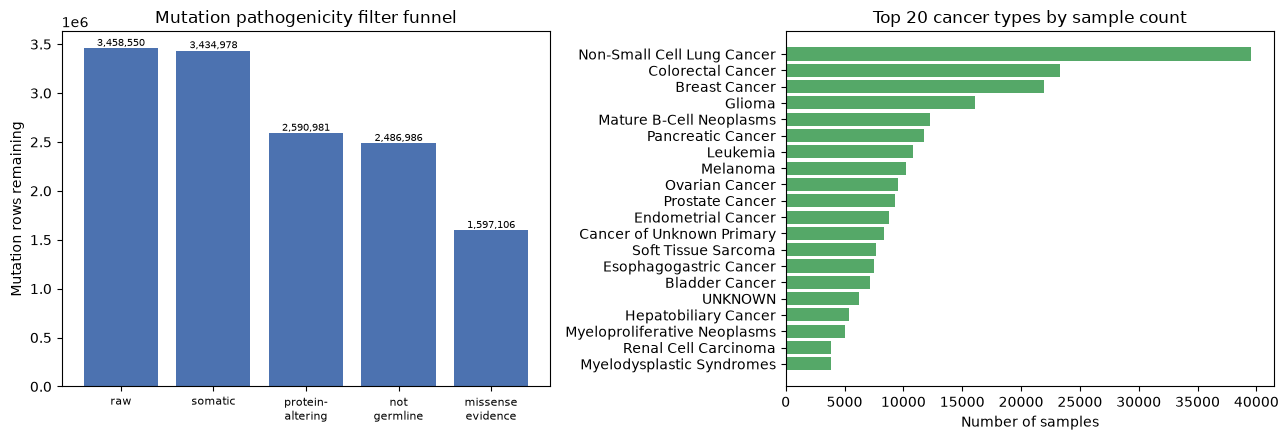

In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

funnel = qc_summary["mutation_filter_funnel"]
FUNNEL_LABELS = {
    "raw_rows": "raw",
    "after_somatic_filter": "somatic",
    "after_protein_altering_filter": "protein-\naltering",
    "after_germline_af_filter": "not\ngermline",
    "after_missense_evidence_filter_FINAL_AM_hotspot_rule": "missense\nevidence",
}
funnel = {k: v for k, v in funnel.items() if k in FUNNEL_LABELS}  # drop the superseded old-rule step
steps = [FUNNEL_LABELS.get(k, k) for k in funnel.keys()]
values = list(funnel.values())
axes[0].bar(range(len(steps)), values, color="#4C72B0")
axes[0].set_xticks(range(len(steps)))
axes[0].set_xticklabels(steps, fontsize=8)
axes[0].set_ylabel("Mutation rows remaining")
axes[0].set_title("Mutation pathogenicity filter funnel")
for i, v in enumerate(values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=7)

top20 = cancer_type_counts.head(20)
axes[1].barh(top20.index[::-1], top20.values[::-1], color="#55A868")
axes[1].set_xlabel("Number of samples")
axes[1].set_title("Top 20 cancer types by sample count")

plt.tight_layout()
plt.show()

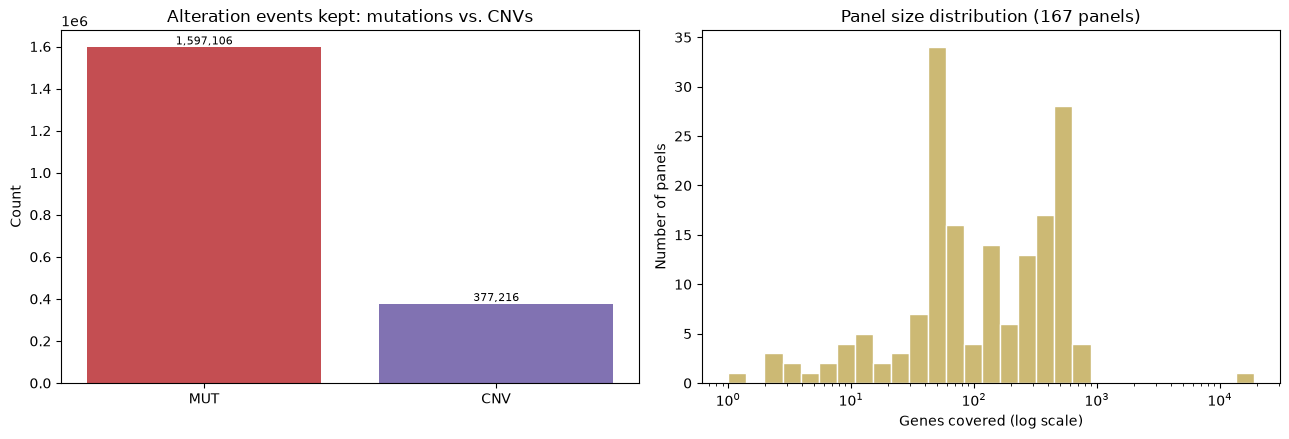

In [26]:
import numpy as np
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

alt_counts = alterations["Alteration_Type"].value_counts()
axes[0].bar(alt_counts.index, alt_counts.values, color=["#C44E52", "#8172B2"])
axes[0].set_ylabel("Count")
axes[0].set_title("Alteration events kept: mutations vs. CNVs")
for i, v in enumerate(alt_counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8)

axes[1].hist(genes_per_panel, bins=np.logspace(np.log10(genes_per_panel.min()), np.log10(genes_per_panel.max()), 30),
             color="#CCB974", edgecolor="white")
axes[1].set_xscale("log")
axes[1].set_xlabel("Genes covered (log scale)")
axes[1].set_ylabel("Number of panels")
axes[1].set_title(f"Panel size distribution ({len(genes_per_panel)} panels)")

plt.tight_layout()
plt.show()

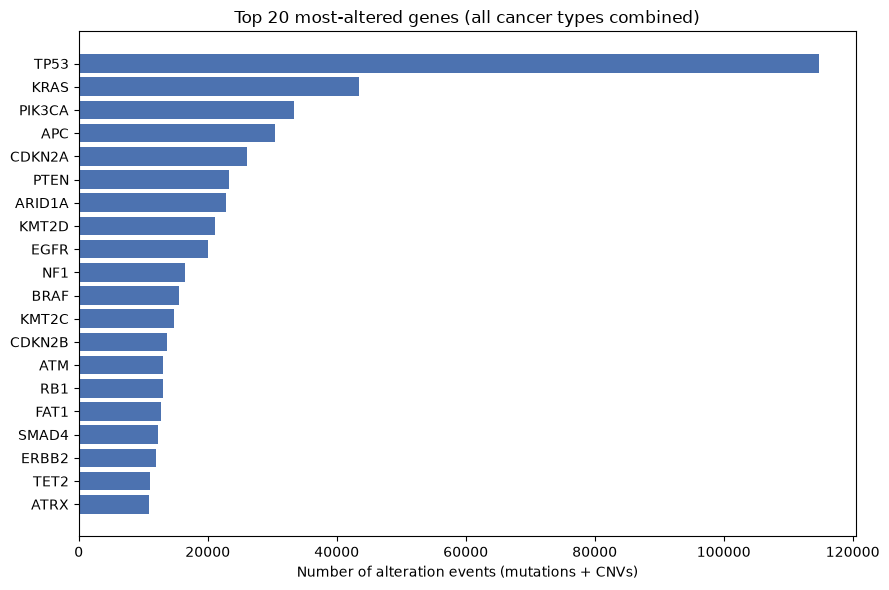

In [27]:
fig, ax = plt.subplots(figsize=(9, 6))
ranked_labels = [f"{gene}" for rank, gene in enumerate(top_genes.index, start=1)]
ax.barh(ranked_labels[::-1], top_genes.values[::-1], color="#4C72B0")
ax.set_xlabel("Number of alteration events (mutations + CNVs)")
ax.set_title("Top 20 most-altered genes (all cancer types combined)")
plt.tight_layout()
plt.show()

## Discussion

**Insight:** the single biggest thing this phase established isn't the
filtering itself, it's that panel coverage has to be tracked explicitly.
Two hospitals reporting "no BRCA1 mutation" can mean completely different
things (tested-and-clean vs. never-tested) depending on which of the 167
panels they used -- ignoring this would silently bias every downstream
frequency calculation toward whichever panels happen to be common. The
consensus-gene-list work (Section 8) builds directly on this: Jason's
point was that samples on different panels aren't comparable unless we
explicitly control for which genes they were actually tested on.

**Result:** 3,458,550 raw mutation rows -> 1,597,106 kept after the
pathogenicity filter (Section 3c's Jason-approved rule: AlphaMissense
pathogenic, OR Polyphen+SIFT agreement, OR a cancerhotspots match);
377,216 high-confidence CNVs kept. Combined: 1,974,322 alteration events
across 229,361 of 271,837 samples. Separately, 23,632 putative two-hit
TSG events found (406 OncoKB-curated genes, shallow deletion + damaging
mutation co-occurring). Two consensus gene lists built: 190 genes
(pooled, >=80% of all samples) and 705 distinct genes (per-cancer-type,
>=80% coverage AND >=100 tested samples within that cancer type).

**Limitations:**
- The AlphaMissense + cancerhotspots rule (Sections 3a/3b) is now applied
  to production (Section 3c), Jason-approved. Still worth noting: this is
  a "best candidate found," not a formally validated-optimal cutoff --
  the tradeoff (stricter, fewer false positives, ~30 genes lose all
  missense evidence) was accepted as reasonable, not proven optimal.
- Only high-confidence CNVs (deep deletion/amplification) are kept in the
  primary matrix. Shallow calls are excluded there but used separately
  for the two-hit TSG feature (Section 5), per Jason's confirmation that
  shallow deletions are useful for confirming biallelic inactivation, not
  as a standalone alteration. TSG membership comes from OncoKB's
  gene-level curation rather than a hand-picked list.
- `data_CNA.txt` contains a small number of `-1.5` values (5,826 cells,
  ~5,042 MSK samples) outside the standard -2/-1/0/1/2 scale -- still
  dropped by the primary `isin([2,-2])` filter, but folded into the
  "shallow deletion" bucket for the two-hit TSG feature (Section 5) since
  they're directionally the same partial-loss signal.
- The two-hit feature can't prove the deletion and mutation are on
  different alleles (no phasing data) -- Jason resolved the practical
  concern (if one copy is deleted, a detected mutation must be on the
  surviving copy), but the "putative" label is kept since this is
  co-occurrence evidence, not directly observed phasing.
- OncoKB's **gene-level** role curation (TSG/ONCOGENE) is used here and is
  free/tokenless. OncoKB's **variant-level** oncogenicity annotation (the
  literal "is this exact mutation oncogenic" call, which is what people
  usually mean by "OncoKB filtering") needs a personal API token
  (free academic registration at oncokb.org) that hasn't been obtained yet
  -- still an open item, not yet built.
- The consensus gene list coverage cutoff (80%) is provisional, per
  Jason's own framing ("we might iterate a few times"). Also, per Jason's
  caveat, picking genes at 80% coverage does NOT remove the need for
  per-sample panel-coverage checking downstream -- the ~20% of samples
  not covered for a given gene must still be excluded from that gene's
  counts in Phase 2, not treated as negatives.

**Open questions (also in `PLAN.md`):** consensus-gene coverage cutoff
(currently 80%, provisional); minimum sample size per cancer type
(currently >=100, provisional); OncoKB variant-level annotation (needs an
API token); whether heme panels should be modeled separately from solid
tumour panels (still unresolved).


## Next steps (Phase 2)

Use `data/processed/alterations_long.parquet` + `panel_gene_coverage.parquet`
to build per-cancer-type binary gene x sample matrices (restricted to
cancer types with >= 100 samples, see count above) and run panel-masked
pairwise Fisher's exact tests for co-occurrence / mutual exclusivity.
See `PLAN.md` Phase 2 for details, and the open questions listed there to
confirm with Jason first (sample-size cutoff, shallow CNA inclusion,
heme vs. solid tumor panel handling).